# Polynomial and regularised regression

The linear model in the previous notebooks underfits California housing. This one adds capacity with
polynomial features, then controls the extra complexity with regularisation:

1. polynomial regression, and picking the degree with a validation curve
2. ridge (L2): fixed alpha, `RidgeCV`, `GridSearchCV`
3. lasso (L1): fixed alpha, `LassoCV`, `GridSearchCV`, and the sparsity it produces
4. SGD with elastic net and `RandomizedSearchCV`
5. comparing the weights and the final test-set errors

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import loguniform, uniform

from sklearn.datasets import fetch_california_housing
from sklearn.dummy import DummyRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, SGDRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import (train_test_split, ShuffleSplit, cross_validate,
                                     validation_curve, GridSearchCV, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

np.random.seed(306)
warnings.simplefilter("ignore", ConvergenceWarning)

Lasso and SGD print a lot of `ConvergenceWarning`s on polynomial features, so they're silenced above.
Where it matters it's mentioned in the text.

In [2]:
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, random_state=42)

cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
cv5 = ShuffleSplit(n_splits=5, test_size=0.2, random_state=42)    # for the bigger searches

In [3]:
def evaluate(model, name, cv=cv):
    res = cross_validate(model, train_features, train_labels, cv=cv,
                         scoring="neg_mean_absolute_error", return_train_score=True,
                         return_estimator=True, n_jobs=-1)
    tr, va = -res['train_score'], -res['test_score']
    print(f"{name:35s} train MAE {tr.mean():.3f} +/- {tr.std():.3f}   valid MAE {va.mean():.3f} +/- {va.std():.3f}")
    return res

In [4]:
lin_res = evaluate(Pipeline([("scale", StandardScaler()), ("lin_reg", LinearRegression())]),
                   "linear regression")

linear regression                   train MAE 0.530 +/- 0.002   valid MAE 0.527 +/- 0.008


## 1. Polynomial regression

`PolynomialFeatures(degree=2)` turns the 8 features into 45: a bias column, the 8 originals, 8 squares and
28 pairwise products. The model is still linear in its weights, so `LinearRegression` fits it the same way.

Scaling comes **after** the polynomial step so the new squared/product columns get scaled too.

In [5]:
poly2 = Pipeline([("poly", PolynomialFeatures(degree=2)),
                  ("scale", StandardScaler()),
                  ("lin_reg", LinearRegression())])
poly_res = evaluate(poly2, "polynomial, degree 2")

polynomial, degree 2                train MAE 0.461 +/- 0.003   valid MAE 0.485 +/- 0.030


In [6]:
poly2_inter = Pipeline([("poly", PolynomialFeatures(degree=2, interaction_only=True)),
                        ("scale", StandardScaler()),
                        ("lin_reg", LinearRegression())])
_ = evaluate(poly2_inter, "polynomial, degree 2, interactions only")

polynomial, degree 2, interactions only train MAE 0.478 +/- 0.003   valid MAE 0.497 +/- 0.024


Both errors dropped compared to the plain linear model, so the extra features help. The training error is
now a bit lower than validation and validation varies more between splits, the first signs of overfitting.
`interaction_only=True` (products but no squares) lands in between.

### Choosing the degree

In [7]:
degrees = [1, 2, 3, 4]
train_scores, valid_scores = validation_curve(
    poly2, train_features, train_labels, param_name="poly__degree", param_range=degrees,
    cv=cv5, scoring="neg_mean_absolute_error", n_jobs=-1)

curve = pd.DataFrame({'train MAE': -train_scores.mean(axis=1),
                      'valid MAE': -valid_scores.mean(axis=1),
                      'valid MAE (median of splits)': -np.median(valid_scores, axis=1)}, index=degrees)
curve.index.name = 'degree'
curve.round(3)

,train MAE,valid MAE,valid MAE (median of splits)
degree,,,
1,0.531,0.525,0.529
2,0.462,0.490,0.467
3,0.417,2.208,0.470
4,0.398,8.014,0.817


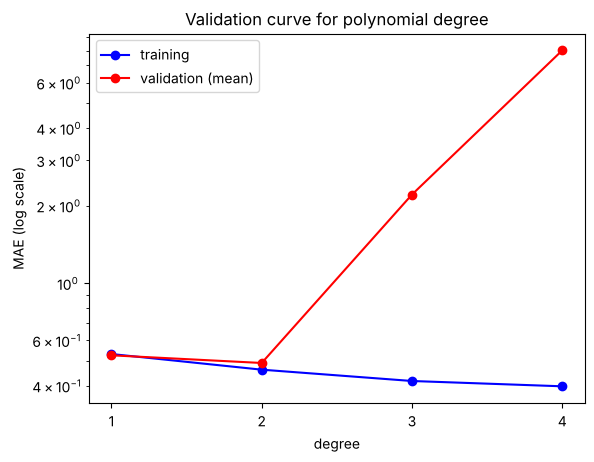

In [8]:
plt.plot(degrees, curve['train MAE'], 'b-o', label='training')
plt.plot(degrees, curve['valid MAE'], 'r-o', label='validation (mean)')
plt.yscale('log')
plt.xlabel('degree'); plt.ylabel('MAE (log scale)')
plt.xticks(degrees)
plt.legend(); plt.title('Validation curve for polynomial degree')
plt.show()

Degree 2 is the best. From degree 3 the training error keeps going down but validation error explodes:
classic overfitting. The mean validation error at high degrees is huge because a few rows with extreme
feature values (the outliers from the EDA) get cubed or raised to the 4th power, and the predictions for
them are absurd. The median over splits shows that on a typical split degree 3 is about as good as
degree 2. It's the occasional split with an extreme row in it that makes it fall apart, and degree 4 is
bad even on typical splits.

(The course version of this cell ran the validation curve on the `interaction_only` pipeline by accident,
because it reused the variable name.)

---

## 2. Ridge regression (L2)

Adds a penalty on the size of the weights to the loss:

$$J(w) = \sum_i (y_i - w^T x_i)^2 + \alpha \sum_j w_j^2$$

Larger `alpha` means smaller weights and a smoother model. It lets us keep the degree 2 features while
holding back the overfitting.

In [9]:
ridge = Pipeline([("poly", PolynomialFeatures(degree=2)),
                  ("scale", StandardScaler()),
                  ("ridge", Ridge(alpha=0.5))])
ridge_res = evaluate(ridge, "ridge, degree 2, alpha=0.5")

ridge, degree 2, alpha=0.5          train MAE 0.481 +/- 0.003   valid MAE 0.487 +/- 0.006


Validation error is about the same as plain degree 2, but it varies much less between splits: the
regularised model is more stable.

### Tuning alpha with RidgeCV

`RidgeCV` tries a list of alphas and keeps the best by cross validation, inside a single `fit`.

In [10]:
alphas = np.logspace(-4, 0, 20)
ridge_cv = Pipeline([("poly", PolynomialFeatures(degree=2)),
                     ("scale", StandardScaler()),
                     ("ridge_cv", RidgeCV(alphas=alphas, cv=cv, scoring="neg_mean_absolute_error"))])
ridge_cv.fit(train_features, train_labels)

print(f"best alpha: {ridge_cv[-1].alpha_:.4f}")
print(f"CV MAE at best alpha: {-ridge_cv[-1].best_score_:.3f}")

best alpha: 0.0078
CV MAE at best alpha: 0.473


Without `cv`, `RidgeCV` uses an efficient leave-one-out shortcut and can store the error for every alpha
(`store_cv_results=True`, called `store_cv_values` in sklearn < 1.5). Wrapping it in `cross_validate`
shows how stable the choice of alpha is:

In [11]:
ridge_loo = Pipeline([("poly", PolynomialFeatures(degree=2)),
                      ("scale", StandardScaler()),
                      ("ridge_cv", RidgeCV(alphas=alphas, store_cv_results=True))])
ridge_loo_res = evaluate(ridge_loo, "RidgeCV (LOO) inside each split")

best_alphas = [est[-1].alpha_ for est in ridge_loo_res['estimator']]
np.round(best_alphas, 4)

RidgeCV (LOO) inside each split     train MAE 0.470 +/- 0.011   valid MAE 0.474 +/- 0.011


array([1.000e+00, 3.793e-01, 1.000e-04, 1.000e-04, 8.860e-02, 8.860e-02,
       2.070e-02, 1.000e+00, 2.070e-02, 1.270e-02])

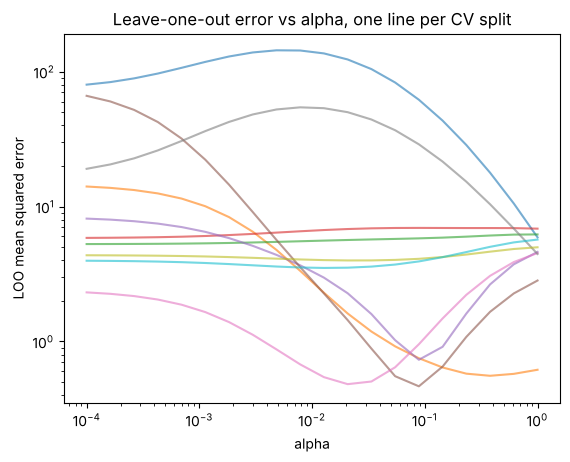

In [12]:
loo_mse = pd.DataFrame([est[-1].cv_results_.mean(axis=0) for est in ridge_loo_res['estimator']],
                       columns=alphas)
loo_mse.T.plot(logx=True, logy=True, legend=False, alpha=0.6)
plt.xlabel('alpha'); plt.ylabel('LOO mean squared error')
plt.title('Leave-one-out error vs alpha, one line per CV split')
plt.show()

The best alpha changes a lot from split to split, anywhere from 1e-4 to 1. Some of the curves are very
flat (alpha barely matters), and a few splits have huge errors at small alphas: those are the splits
where an extreme row ended up in the training data and the unregularised fit went wild for it.
With the best alpha all over the place, I'd rather pick it with a proper search over the whole pipeline.

### GridSearchCV over degree and alpha together

In [13]:
ridge_grid = GridSearchCV(
    Pipeline([("poly", PolynomialFeatures()), ("scale", StandardScaler()), ("ridge", Ridge())]),
    param_grid={'poly__degree': [1, 2, 3], 'ridge__alpha': np.logspace(-4, 0, 10)},
    cv=cv5, scoring="neg_mean_absolute_error", return_train_score=True, n_jobs=-1)
ridge_grid.fit(train_features, train_labels)

i = ridge_grid.best_index_
print("best params:", ridge_grid.best_params_)
print(f"train MAE: {-ridge_grid.cv_results_['mean_train_score'][i]:.3f} +/- {ridge_grid.cv_results_['std_train_score'][i]:.3f}")
print(f"valid MAE: {-ridge_grid.cv_results_['mean_test_score'][i]:.3f} +/- {ridge_grid.cv_results_['std_test_score'][i]:.3f}")

best params: {'poly__degree': 2, 'ridge__alpha': np.float64(0.016681005372000592)}
train MAE: 0.465 +/- 0.003
valid MAE: 0.476 +/- 0.018


(The course version printed the training std for both lines, a copy-paste slip.)

---

## 3. Lasso regression (L1)

Same idea with an absolute-value penalty:

$$J(w) = \frac{1}{2n} \sum_i (y_i - w^T x_i)^2 + \alpha \sum_j |w_j|$$

The L1 penalty pushes some weights to **exactly zero**, so lasso also does feature selection.

In [14]:
lasso = Pipeline([("poly", PolynomialFeatures(degree=2)),
                  ("scale", StandardScaler()),
                  ("lasso", Lasso(alpha=0.01, max_iter=5000))])
lasso_res = evaluate(lasso, "lasso, degree 2, alpha=0.01")

lasso, degree 2, alpha=0.01         train MAE 0.529 +/- 0.003   valid MAE 0.528 +/- 0.008


In [15]:
n_zero = [int((est[-1].coef_ == 0).sum()) for est in lasso_res['estimator']]
print("weights set to zero (out of 45):", n_zero)

weights set to zero (out of 45): [29, 28, 31, 30, 31, 31, 29, 29, 30, 30]


At alpha=0.01 most of the 45 polynomial weights are exactly zero, but the error is back to about linear
regression level, so this alpha is too strong.

### LassoCV

In [16]:
lasso_cv = Pipeline([("poly", PolynomialFeatures(degree=2)),
                     ("scale", StandardScaler()),
                     ("lasso_cv", LassoCV(alphas=np.logspace(-5, -1, 15), cv=cv5, max_iter=5000))])
lasso_cv_res = evaluate(lasso_cv, "LassoCV inside each split", cv=cv5)

print("best alphas:", np.round([est[-1].alpha_ for est in lasso_cv_res['estimator']], 5))

LassoCV inside each split           train MAE 0.520 +/- 0.017   valid MAE 0.518 +/- 0.016
best alphas: [1.389e-02 7.200e-03 4.000e-05 7.200e-03 7.200e-03]


Worse than the fixed-alpha ridge. `LassoCV` always chooses alpha by mean squared error, while everything
here is measured in MAE, and on this data MSE is dominated by a few rows with huge errors, which pushes
it towards larger alphas on some splits. (This cell had no output in the course colab, it never finished
running there.)

### GridSearchCV over degree and alpha

In [17]:
lasso_grid = GridSearchCV(
    Pipeline([("poly", PolynomialFeatures()), ("scale", StandardScaler()), ("lasso", Lasso(max_iter=5000))]),
    param_grid={'poly__degree': [1, 2, 3], 'lasso__alpha': np.logspace(-4, -1, 7)},
    cv=cv5, scoring="neg_mean_absolute_error", return_train_score=True, n_jobs=-1)
lasso_grid.fit(train_features, train_labels)

i = lasso_grid.best_index_
print("best params:", lasso_grid.best_params_)
print(f"train MAE: {-lasso_grid.cv_results_['mean_train_score'][i]:.3f}")
print(f"valid MAE: {-lasso_grid.cv_results_['mean_test_score'][i]:.3f} +/- {lasso_grid.cv_results_['std_test_score'][i]:.3f}")

best params: {'lasso__alpha': np.float64(0.0001), 'poly__degree': 3}
train MAE: 0.455
valid MAE: 0.484 +/- 0.033


In [18]:
best_lasso = lasso_grid.best_estimator_
names = best_lasso['poly'].get_feature_names_out(features.columns)
coef = pd.Series(best_lasso['lasso'].coef_, index=names)
print(f"{(coef == 0).sum()} of {len(coef)} weights are zero")
coef[coef != 0].abs().sort_values(ascending=False).head(10).round(3)

43 of 165 weights are zero


MedInc^2 Longitude              1.780
MedInc^2 AveOccup               1.697
Latitude^3                      1.447
AveOccup Longitude^2            1.438
MedInc AveBedrms AveOccup       1.397
Population AveOccup Latitude    1.339
HouseAge                        1.229
AveOccup Latitude^2             1.186
AveRooms Latitude^2             1.178
Latitude Longitude^2            1.147
dtype: float64

The grid search picked degree 3 with a very small alpha. That model still has 122 non-zero weights, so at
this alpha the lasso isn't doing much feature selection, it's mostly keeping the degree 3 model from
blowing up the way plain degree 3 did in the validation curve.

---

## 4. SGD with elastic net

`SGDRegressor(penalty='elasticnet')` mixes L1 and L2: `l1_ratio=1` is lasso, `0` is ridge. With default
settings on polynomial features it diverges, same as in the SGD notebook:

In [19]:
poly_sgd = Pipeline([("poly", PolynomialFeatures()),
                     ("scale", StandardScaler()),
                     ("sgd", SGDRegressor(penalty='elasticnet', random_state=42))])
_ = evaluate(poly_sgd, "SGD elasticnet, defaults", cv=cv5)

SGD elasticnet, defaults            train MAE 10588742987.344 +/- 3589007987.407   valid MAE 10945636091.613 +/- 3413388623.149


`RandomizedSearchCV` samples `n_iter` combinations from distributions instead of trying every combination
on a grid. Good when there are several hyperparameters and some are continuous. `loguniform` is the
right choice for things like learning rates, where 1e-5 vs 1e-4 matters as much as 0.1 vs 1.

In [20]:
param_distributions = {
    'poly__degree': [1, 2, 3],
    'sgd__learning_rate': ['constant', 'adaptive', 'invscaling'],
    'sgd__l1_ratio': uniform(0, 1),
    'sgd__eta0': loguniform(1e-5, 1e-2),
    'sgd__power_t': uniform(0, 1),
}

sgd_search = RandomizedSearchCV(poly_sgd, param_distributions=param_distributions, n_iter=20,
                                cv=cv5, scoring='neg_mean_absolute_error', random_state=0, n_jobs=-1)
sgd_search.fit(train_features, train_labels)

print(f"best CV MAE: {-sgd_search.best_score_:.3f}")
{k: (round(v, 6) if isinstance(v, float) else v) for k, v in sgd_search.best_params_.items()}

best CV MAE: 0.525


{'poly__degree': 1,
 'sgd__eta0': np.float64(8.8e-05),
 'sgd__l1_ratio': np.float64(0.363711),
 'sgd__learning_rate': 'adaptive',
 'sgd__power_t': np.float64(0.038425)}

In [21]:
search_res = pd.DataFrame(sgd_search.cv_results_)
search_res['valid MAE'] = -search_res['mean_test_score']
cols = ['param_poly__degree', 'param_sgd__learning_rate', 'param_sgd__eta0', 'valid MAE']
search_res.sort_values('valid MAE')[cols].head(8)

,param_poly__degree,param_sgd__learning_rate,param_sgd__eta0,valid MAE
11,1,adaptive,0.000088,0.525472
3,2,constant,0.000016,0.526951
19,3,invscaling,0.000496,0.683659
0,1,adaptive,0.000601,0.956026
16,3,invscaling,0.008238,1.827052
17,2,invscaling,0.001651,2.012341
13,1,constant,0.000557,12.989421
15,1,adaptive,0.000972,54.490743


The upper end of the original `eta0` range (up to 1) only produced diverged models, so it's capped at
1e-2 here. Even so, most sampled combinations blow up, and the best one is degree 1, i.e. plain linear
regression again. In 20 random tries it never found settings that make use of the polynomial features.
SGD on polynomial features of this data is fragile.

---

## 5. Comparing weights

Degree 2 without regularisation vs ridge, across the 10 CV splits:

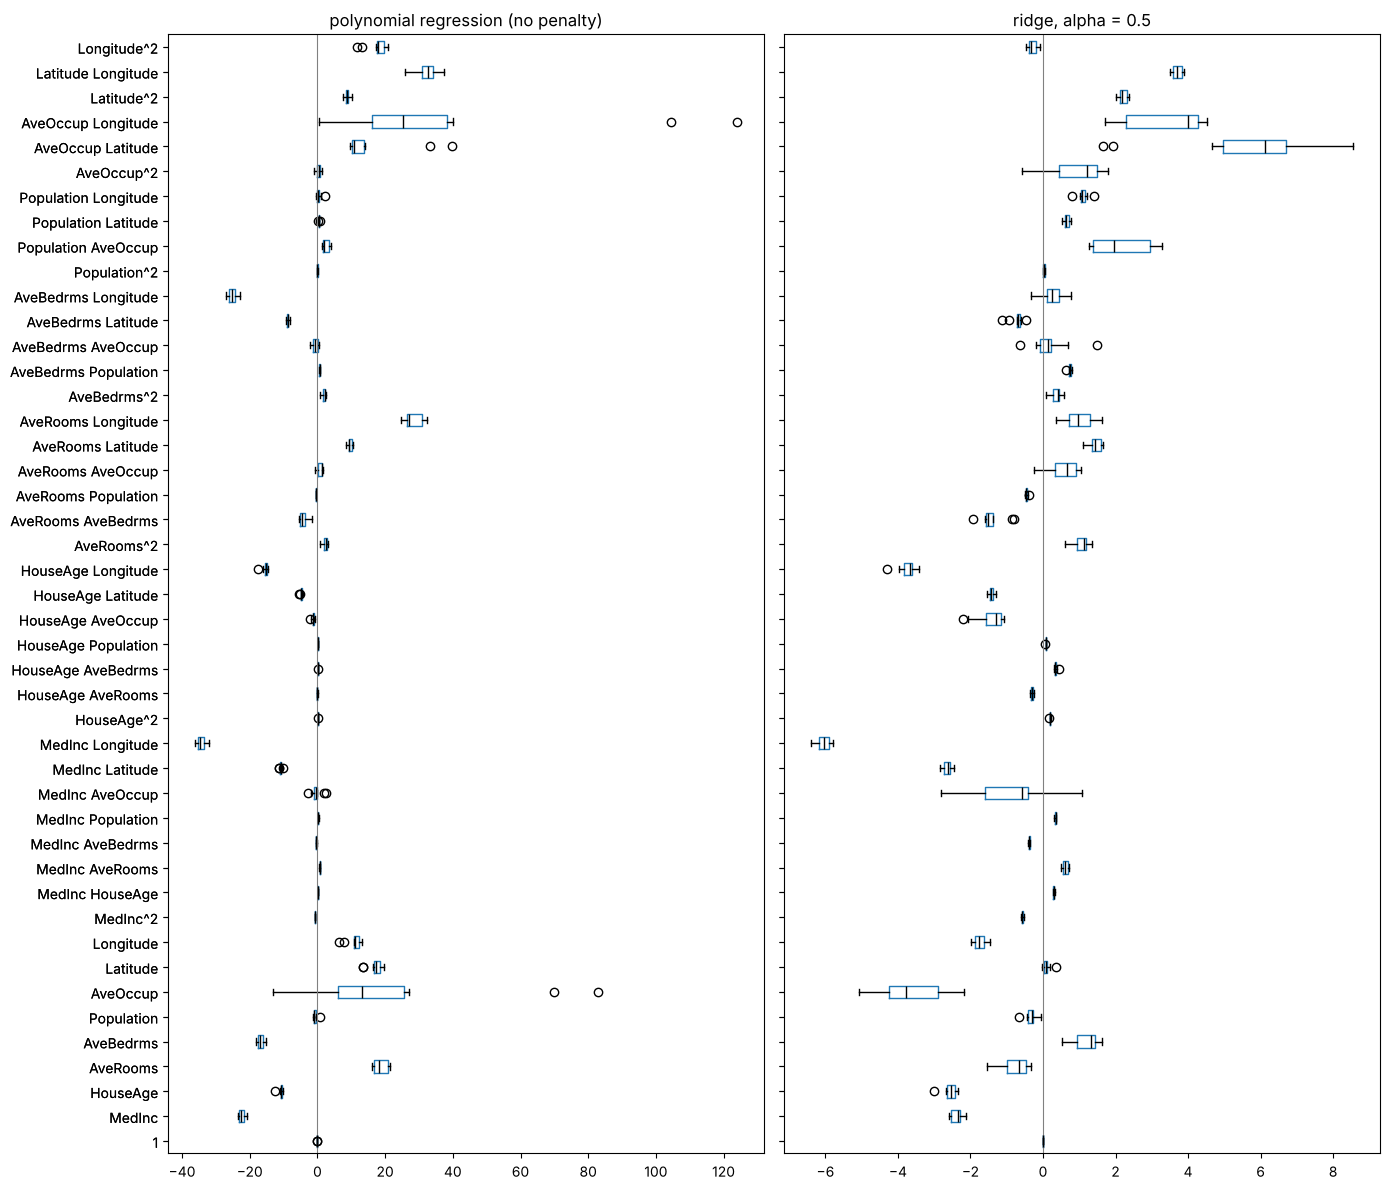

In [22]:
names = poly_res['estimator'][0]['poly'].get_feature_names_out(features.columns)
w_poly = pd.DataFrame([est[-1].coef_ for est in poly_res['estimator']], columns=names)
w_ridge = pd.DataFrame([est[-1].coef_ for est in ridge_res['estimator']], columns=names)

fig, axes = plt.subplots(1, 2, figsize=(14, 12), sharey=True)
style = {"whiskers": "black", "medians": "black", "caps": "black"}
w_poly.plot.box(vert=False, color=style, ax=axes[0]); axes[0].set_title('polynomial regression (no penalty)')
w_ridge.plot.box(vert=False, color=style, ax=axes[1]); axes[1].set_title('ridge, alpha = 0.5')
for ax in axes:
    ax.axvline(0, c='grey', lw=0.8)
plt.tight_layout()
plt.show()

In [23]:
pd.DataFrame({'no penalty': w_poly.std(), 'ridge': w_ridge.std()}).describe().loc[['mean', 'max']].round(3)

,no penalty,ridge
mean,2.630,0.306
max,41.317,2.189


Without a penalty some weights swing widely between splits, mainly the ones involving AveRooms,
AveBedrms and AveOccup, which are correlated with each other and contain the extreme values. Ridge keeps
those under control.

## 6. Test set

Everything above used only the training data. Now each model is refitted on the full training set and
evaluated once on the test set.

In [24]:
final_models = {
    'baseline (median)': DummyRegressor(strategy='median'),
    'linear regression': Pipeline([("scale", StandardScaler()), ("lin_reg", LinearRegression())]),
    'polynomial (degree 2)': poly2,
    'ridge (grid search)': ridge_grid.best_estimator_,
    'lasso (grid search)': lasso_grid.best_estimator_,
    'SGD elasticnet (random search)': sgd_search.best_estimator_,
}

rows = []
for name, model in final_models.items():
    model.fit(train_features, train_labels)
    pred = model.predict(test_features)
    rows.append({'model': name,
                 'test MAE': mean_absolute_error(test_labels, pred),
                 'test MAPE': mean_absolute_percentage_error(test_labels, pred)})

pd.DataFrame(rows).set_index('model').round(3)

,test MAE,test MAPE
model,,
baseline (median),0.881,0.533
linear regression,0.530,0.320
polynomial (degree 2),0.465,0.270
ridge (grid search),0.465,0.272
lasso (grid search),0.466,0.279
SGD elasticnet (random search),0.530,0.319


* polynomial features help: test MAE goes from 0.53 to about 0.47
* on the test set ridge and lasso end up level with plain degree 2. What regularisation bought here is
  stability: much smaller spread across CV splits, and no weights swinging into the 40s
* the SGD search only got as far as plain linear regression

## Summary

| | adds | controls |
|---|---|---|
| `PolynomialFeatures` | capacity (squares, interactions) | `degree`, `interaction_only` |
| `Ridge` | L2 penalty, shrinks all weights | `alpha` |
| `Lasso` | L1 penalty, sets some weights to 0 | `alpha` |
| `SGDRegressor(penalty='elasticnet')` | mix of both | `alpha`, `l1_ratio`, plus all the SGD settings |

Tools for tuning: `validation_curve` for one parameter, `RidgeCV` / `LassoCV` for alpha,
`GridSearchCV` / `RandomizedSearchCV` for everything at once.